# 04 — Résultats des modèles

## Objectif

Ce notebook présente **tous les résultats** : les choix faits sur la validation 2023, puis le test
final 2024-2025. Il ne calcule aucun modèle : il **lit les fichiers** de `data/resultats/`,
écrits par les commandes du projet (voir le README) :

| Commande | Ce qu'elle écrit |
|---|---|
| `python -m src.experiences` | choix sur 2023 : ablations, course des températures, grilles de M3 et M4 |
| `python -m src.experiences --test-final` | prévisions 2024-2025 des configurations **gelées** |
| `python -m src.analyses --test-final` | plafond « météo parfaite », décision 14, sensibilité au Covid, diagnostic de M4, erreurs par groupe, significativité, pires jours |
| `python -m src.comparaison --test-final` | toutes les méthodes notées **sur les mêmes jours** |
| `python -m src.test_bonus` | test bonus janvier-juin 2026, lancé **une seule fois** |

Aucun chiffre n'est donc tapé à la main ici : si on relance les commandes, le notebook suit.

## Les méthodes comparées

| Nom | Ce qu'elle fait | Apprend ? |
|---|---|---|
| B0 | recopie la « veille effective » (jour J pour 0-12 h, J-1 pour 13-23 h) | non |
| B1 | recopie le même jour de la semaine précédente | non |
| B2 | moyenne des 4 mêmes jours précédents | non |
| M1 | régression : calendrier + consommations passées connues à 14 h | oui |
| M2 | M1 + température connue à 14 h | oui |
| M3 | gradient boosting avec les variables de M2 | oui |
| M4 | M1 + correction ARMA de ses erreurs récentes | oui |
| Plafond | M2 + **vraie** température du jour cible | oui, mais **impossible à 14 h** |

Le plafond n'est pas un modèle utilisable : il répond à la question « combien gagnerait-on avec
une prévision météo parfaite ? ».

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RACINE = Path.cwd().resolve()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

RESULTATS = RACINE / "data" / "resultats"
lire = lambda nom: pd.read_csv(RESULTATS / f"{nom}.csv")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

BLEU, ORANGE, VERT, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#9a9890"
ENCRE, GRIS_TEXTE = "#2b3440", "#52514e"
plt.rcParams.update({
    "figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": GRIS_TEXTE, "xtick.color": GRIS_TEXTE,
    "ytick.color": GRIS_TEXTE, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 1.5,
})

# Noms courts pour les tableaux et les graphiques
COURT = {
    "B0 : veille effective": "B0", "B1 : semaine précédente": "B1",
    "B2 : moyenne de 4 semaines": "B2", "M1 : calendrier + retards": "M1",
    "M2 : M1 + température": "M2", "M3 : gradient boosting": "M3",
    "M4 : M1 + ARMA": "M4", "Plafond : M2 + météo parfaite": "Plafond",
}
COULEUR = {"B0": GRIS, "B1": GRIS, "B2": GRIS, "M1": BLEU, "M2": ORANGE, "M3": BLEU,
           "M4": BLEU, "Plafond": VERT}

## 1. Le résultat principal : toutes les méthodes sur les mêmes jours

Je compare les 8 méthodes **sur exactement les mêmes jours** : ceux où toutes ont leurs 24 heures
(l'énoncé demande les mêmes dates). Les jours de changement d'heure (23 h ou 25 h) ne sont jamais
notés.

In [2]:
def tableau_comparaison(nom):
    t = lire(nom).set_index("methode").rename(index=COURT)
    colonnes = ["nb_jours", "MAE (MW)", "RMSE (MW)", "MAPE (%)", "biais (MW)",
                "erreur énergie du jour (GWh, absolue)", "erreur pointe (MW, absolue)",
                "écart heure de pointe (h)"]
    return t[colonnes]

validation = tableau_comparaison("comparaison_validation_2023")
test = tableau_comparaison("comparaison_test_2024_2025")
print("Validation 2023")
display(validation.round(1))
print("Test 2024-2025")
display(test.round(1))

Validation 2023


,nb_jours,MAE (MW),RMSE (MW),MAPE (%),biais (MW),"erreur énergie du jour (GWh, absolue)","erreur pointe (MW, absolue)",écart heure de pointe (h)
methode,,,,,,,,
B0,361.0,3312.7,4527.4,6.7,-15.1,75.7,3558.2,1.8
B1,361.0,3467.6,5009.2,6.5,-33.9,80.6,3795.9,1.8
B2,361.0,4162.4,5872.4,7.9,23.1,96.9,4389.9,1.5
M1,361.0,1546.7,2149.8,3.0,620.9,32.8,1709.2,1.4
M2,361.0,1500.1,2049.5,3.0,1012.0,32.8,1615.5,1.3
M3,361.0,1579.8,2253.9,3.0,1075.1,33.5,1854.0,1.7
M4,361.0,1519.9,2142.2,3.0,481.5,31.8,1653.5,1.7
Plafond,361.0,1251.0,1666.9,2.5,931.5,27.0,1348.4,1.3


Test 2024-2025


,nb_jours,MAE (MW),RMSE (MW),MAPE (%),biais (MW),"erreur énergie du jour (GWh, absolue)","erreur pointe (MW, absolue)",écart heure de pointe (h)
methode,,,,,,,,
B0,723.0,3204.8,4376.8,6.4,-67.5,72.6,3332.0,2.3
B1,723.0,3337.0,4997.0,6.2,-153.2,76.7,3458.0,2.1
B2,723.0,3648.8,5223.6,6.9,-141.4,85.0,3735.3,1.8
M1,723.0,1584.3,2296.0,3.0,341.7,33.9,1731.1,1.9
M2,723.0,1330.6,1855.9,2.6,517.9,28.4,1454.6,1.8
M3,723.0,1349.3,1951.2,2.6,582.9,27.5,1517.4,2.1
M4,723.0,1591.4,2321.0,3.0,271.5,33.6,1744.1,2.0
Plafond,723.0,1044.0,1419.2,2.1,463.0,21.3,1128.1,1.6


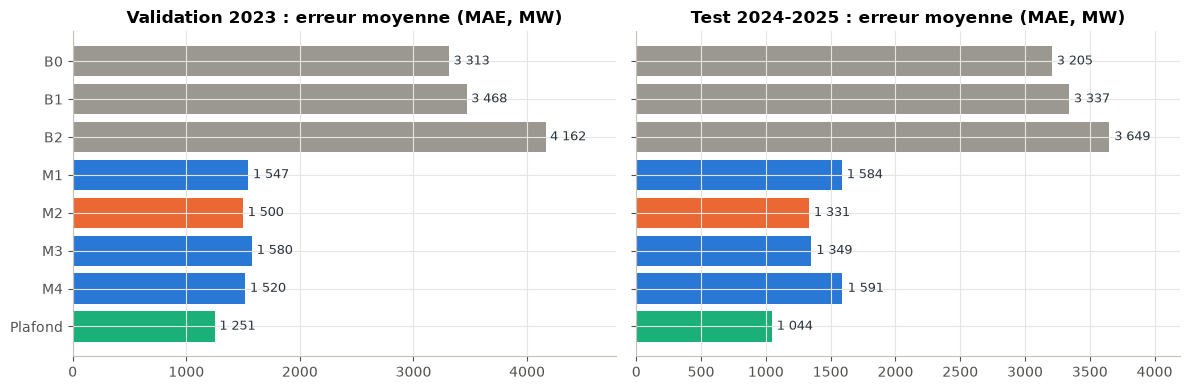

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (titre, t) in zip(axes, [("Validation 2023", validation), ("Test 2024-2025", test)]):
    mae = t["MAE (MW)"]
    ax.barh(mae.index[::-1], mae[::-1], color=[COULEUR[m] for m in mae.index[::-1]])
    for y, v in enumerate(mae[::-1]):
        ax.text(v + 40, y, f"{v:,.0f}".replace(",", " "), va="center", fontsize=9, color=ENCRE)
    ax.set_title(f"{titre} : erreur moyenne (MAE, MW)")
    ax.set_xlim(0, mae.max() * 1.15)
plt.tight_layout()
plt.show()

**Ce que je lis :**

- Tous les modèles battent largement les benchmarks : M1 divise déjà l'erreur de B0 par deux. Le
  calendrier et les bons retards (connus à 14 h) font l'essentiel du travail.
- **M2 a la plus petite erreur des modèles utilisables**, en 2023 comme sur le test. La
  température apporte peu en 2023 (de 1 547 à 1 500 MW) mais beaucoup plus sur le test (de 1 584
  à 1 331 MW).
- **M3 (gradient boosting) fait presque aussi bien que M2 sur le test** (1 349 MW), mais pas mieux.
  Le point 8 vérifie si ces écarts sont réels ou dus au hasard.
- **M4 n'apporte rien** une fois corrigée la petite fuite de l'heure 13 (voir `docs/decisions.md`) :
  il est au niveau de M1 sur le test. Le point 5 explique pourquoi.
- Le **plafond** gagne encore environ 20 % sur M2 : c'est ce qu'une prévision météo parfaite
  apporterait. Nous n'avons que la température observée jusqu'à 13 h, pas de prévision.

## 2. Un défaut commun : les modèles prévoient trop

Le **biais** est l'erreur moyenne avec son signe : positif = on prévoit trop. Les benchmarks ont un
biais proche de 0, mais **tous les modèles prévoient trop**, même le plafond. Je regarde mois par mois.

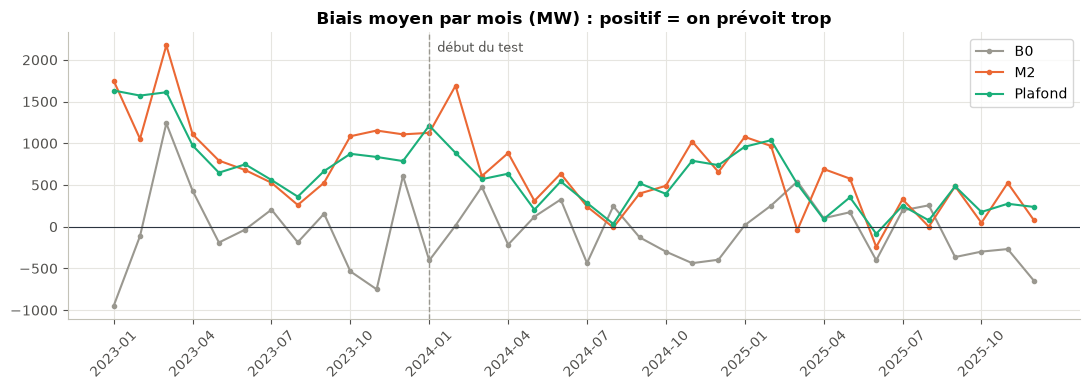

Part des mois où M2 prévoit trop : 92% (33 mois sur 36)


In [4]:
mois = pd.concat([lire("erreurs_par_groupe_2023"), lire("erreurs_par_groupe_2024_2025")])
mois = mois[mois["critere"] == "mois"].assign(methode=lambda d: d["methode"].map(COURT))
biais = mois.pivot(index="groupe", columns="methode", values="biais_MW")

fig, ax = plt.subplots()
for m in ["B0", "M2", "Plafond"]:
    ax.plot(biais.index, biais[m], marker="o", ms=3, color=COULEUR[m], label=m)
ax.axhline(0, color=ENCRE, lw=0.8)
ax.axvline("2024-01", color=GRIS, ls="--", lw=1)
ax.text("2024-01", ax.get_ylim()[1] * 0.9, "  début du test", color=GRIS_TEXTE, fontsize=9)
ax.set_title("Biais moyen par mois (MW) : positif = on prévoit trop")
ax.set_xticks(biais.index[::3])
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print("Part des mois où M2 prévoit trop :",
      f"{(biais['M2'] > 0).mean():.0%}", f"({(biais['M2'] > 0).sum()} mois sur {len(biais)})")

**Ce que je lis :** M2 prévoit trop presque tous les mois, surtout en 2023 (souvent plus de
1 000 MW) puis de moins en moins. Le plafond, qui connaît la vraie météo, a le même défaut : ce
n'est donc **pas la météo**.

Mon explication, à présenter comme une hypothèse : depuis l'hiver 2022-2023 (crise de l'énergie,
sobriété), la France consomme moins qu'avant à calendrier et température égaux. Les modèles
apprennent sur 2016-2022 avec le même poids pour toutes les années, donc ils gardent en mémoire
un niveau trop haut. Les benchmarks, eux, recopient des jours récents : ils suivent le niveau et
n'ont presque pas de biais.

Je ne corrige pas ce défaut maintenant, car le test a déjà été vu (ce serait régler le modèle sur
le test). C'est la **première piste d'amélioration** : une variable de tendance, ou donner plus de
poids aux années récentes, à choisir sur la validation.

## 3. Ce que chaque ingrédient apporte (ablation, validation 2023)

L'énoncé demande de mesurer l'effet de chaque type de variable. Tous ces choix ont été faits
**sur 2023 seulement**.

In [5]:
retards = lire("ablation_lags_m1_2023")[["variante", "MAE_MW", "RMSE_MW"]]
retards["retards utilisés"] = retards["variante"].map({
    "LAG-A": "veille effective (H ≤ 12) + 168 h",
    "LAG-B": "veille effective (H ≤ 12) + 48 h + 168 h",
    "LAG-C": "48 h + 168 h",
    "LAG-D": "168 h seulement",
})
retards["retenue"] = np.where(retards["variante"] == "LAG-B", "oui", "")
print("Retards de consommation (M1)")
display(retards.round(0))

calendrier = lire("ablation_calendrier_m1_2023")[["variante", "variables", "MAE_MW"]]
print("Calendrier (M1) ; jour de la semaine et mois toujours présents")
display(calendrier.round(1))

Retards de consommation (M1)


,variante,MAE_MW,RMSE_MW,retards utilisés,retenue
0,LAG-B,1548.0,2151.0,veille effective (H ≤ 12) + 48 h + 168 h,oui
1,LAG-C,1959.0,2634.0,48 h + 168 h,
2,LAG-A,2204.0,3141.0,veille effective (H ≤ 12) + 168 h,
3,LAG-D,3378.0,4344.0,168 h seulement,


Calendrier (M1) ; jour de la semaine et mois toujours présents


,variante,variables,MAE_MW
0,CAL-D,ferie + veille_ferie + lendemain_ferie + pont_potentiel + vacances_A + vacances_B + vacances_C,1548.0
1,CAL-E,ferie + veille_ferie + lendemain_ferie + pont_potentiel + vacances_A + vacances_B + vacances_C + periode_noel,1548.9
2,CAL-B,ferie + veille_ferie + lendemain_ferie + pont_potentiel,1549.5
3,CAL-C,ferie + veille_ferie + lendemain_ferie + pont_potentiel + nb_zones_vacances,1555.0
4,CAL-F,ferie + veille_ferie + lendemain_ferie + pont_potentiel + nb_zones_vacances + periode_noel,1555.9
5,CAL-A,ferie,1601.2


**Ce que je lis :**

- Les **retards** sont l'ingrédient le plus important : sans la consommation de la veille et de
  l'avant-veille (LAG-D), l'erreur double.
- Le **calendrier** compte surtout par les jours fériés et leurs voisins (veille, lendemain, pont).
  Les vacances scolaires apportent très peu, et la période de Noël n'apporte rien **en moyenne** :
  elle n'a pas été retenue. On verra au point 7 que ce choix coûte cher le 24 décembre.

In [6]:
meteo = lire("ablation_m2_2023")
print("Les 3 températures France avec toutes les variables météo (M2-F)")
display(meteo[meteo["variante_meteo"] == "M2-F"][["candidat_temperature", "MAE_MW", "RMSE_MW"]].round(1))

print("Les variantes météo, avec la température retenue")
variantes = meteo[meteo["candidat_temperature"] == "temp_38_ponderee"]
display(variantes[["variante_meteo", "nb_variables_meteo", "MAE_MW", "gain_MAE_vs_M1_MW"]].round(1))

Les 3 températures France avec toutes les variables météo (M2-F)


,candidat_temperature,MAE_MW,RMSE_MW
0,temp_38_ponderee,1503.5,2052.9
1,temp_8_villes,1504.3,2066.2
2,temp_38_simple,1504.4,2050.5


Les variantes météo, avec la température retenue


,variante_meteo,nb_variables_meteo,MAE_MW,gain_MAE_vs_M1_MW
0,M2-F,7,1503.5,44.4
4,M2-E,6,1520.8,27.1
7,M2-D,4,1549.0,-1.0
12,M2-C,3,1579.5,-31.6
14,M2-B,2,1584.1,-36.2
17,M2-A,1,1646.1,-98.1


**Ce que je lis :**

- La course des 3 températures est une **égalité** : moins de 1 MW d'écart de MAE. La moyenne
  pondérée par la consommation régionale (`temp_38_ponderee`) a été retenue car c'est la meilleure
  sur 2023, mais les 8 villes donneraient le même résultat. Je l'écris tel quel dans le rapport.
- La température seule à 13 h (M2-A) fait **moins bien** que M1. Ce qui aide, ce sont les degrés
  de chauffage (froid) et de climatisation (chaleur) et la température lissée sur plusieurs jours
  (inertie des bâtiments) : la relation n'est pas une ligne droite (notebook 02).

In [7]:
display(lire("sensibilite_covid_2023").round(1))

,modele,confinement_retire,MAE_MW,RMSE_MW,MAE_pointe_MW
0,M1,True,1548.0,2151.1,1711.7
1,M2,True,1503.5,2052.9,1617.0
2,M1,False,1520.3,2121.1,1677.0
3,M2,False,1410.5,1939.9,1515.7


**Le confinement (décision 9).** Nous avions décidé de retirer de l'apprentissage les jours du
17 mars au 17 mai 2020, et promis de vérifier ce choix sur 2023. Ce test n'a été fait **qu'après**
le gel des modèles, et il donne tort à la décision : en gardant ces jours, M2 aurait fait 1 411 MW
au lieu de 1 504 MW en 2023.

Mon explication : ces jours de très faible consommation tirent vers le bas le niveau que le modèle
apprend, ce qui compense en partie la surestimation de 2023 (point 2). Ce n'est donc pas « le
Covid aide » mais un autre signe du même problème de niveau. Je ne change pas le modèle gelé, car
le test a déjà été vu : je l'écris comme une limite.

## 4. Décision 14 : 24 modèles ou un seul ?

Nous avions décidé de faire **un modèle par heure** (24 régressions) et promis d'essayer la version
« un seul modèle, l'heure comme variable » sur 2023.

In [8]:
display(lire("decision14_un_modele_contre_24_2023").round(1))

,forme,MAE_MW,RMSE_MW,MAE_total_journalier_MWh,MAE_pointe_MW,MAE_heure_pointe_h,nb_jours_complets
0,24 modèles (un par heure),1548.0,2151.1,32776.4,1711.7,1.5,363
1,1 modèle (heure en variable),2096.0,2747.8,36907.8,1961.1,1.6,363


**Ce que je lis :** le modèle unique est nettement moins bon. Avec une seule régression, l'effet du
jour de la semaine ou de la consommation passée est le même à 4 h et à 19 h, ce qui est faux. Les 24
modèles permettent à chaque heure d'avoir ses propres effets : la décision 14 est confirmée.

## 5. Les réglages de M3 et M4 (validation 2023)

In [9]:
print("M3 : gradient boosting")
display(lire("selection_m3_validation_2023").round(2))
print("M4 : correction ARMA(p, q) des erreurs de M1")
display(lire("selection_m4_validation_2023").round(2))

M3 : gradient boosting


,configuration,learning_rate,max_iter,max_leaf_nodes,l2_regularization,MAE_MW,RMSE_MW,MAE_total_journalier_MWh,MAE_pointe_MW,MAE_heure_pointe_h
0,M3-1,0.05,300,15,1.0,1579.72,2251.87,33475.39,1854.19,1.67
1,M3-2,0.05,300,31,1.0,1599.03,2300.39,33434.20,1921.34,1.86
2,M3-4,0.10,200,31,1.0,1611.68,2317.02,33350.69,1918.57,1.84
3,M3-3,0.05,300,63,1.0,1653.58,2387.28,33854.46,1956.71,1.71


M4 : correction ARMA(p, q) des erreurs de M1


,configuration,p,q,MAE_MW,RMSE_MW,MAE_total_journalier_MWh,MAE_pointe_MW,MAE_heure_pointe_h,nb_observations
0,M4-1,1,0,1521.09,2143.32,31824.41,1656.24,1.77,8712
1,M4-4,2,1,1527.07,2131.04,32256.20,1672.26,1.58,8712
2,M4-3,1,1,1527.54,2135.50,32293.58,1678.62,1.53,8712
3,M4-2,2,0,1557.98,2184.61,33024.32,1722.61,1.71,8712


**Ce que je lis :** pour M3, les arbres les plus simples (15 feuilles) sont les meilleurs : avec plus
de feuilles, le modèle apprend trop les détails de l'apprentissage. Pour M4, l'ARMA(1, 0) est retenu :
c'est un simple AR(1), le plus simple des quatre ARMA essayés. Dans les deux cas, la règle était
fixée à l'avance : la plus petite MAE de 2023.

**Pourquoi M4 n'aide pas ?** M4 corrige la prévision avec l'erreur de M1 de la veille (heures 0 à
12) ou de l'avant-veille (heures 13 à 23, car l'erreur de la veille n'est pas encore connue à 14 h).
Ça ne marche que si les erreurs se répètent d'un jour à l'autre, à la même heure.

In [10]:
display(lire("diagnostic_m4_2023").round(2))

,erreurs_de_M1,moyenne_MW,ecart_type_MW,autocorrelation_1_jour,autocorrelation_2_jours
0,apprentissage 2016-2022 (ce que voit M4),-0.00,2270.96,0.28,0.02
1,validation 2023 (erreurs réelles),-609.44,2063.09,0.24,-0.04


Les erreurs de M1 ne se répètent qu'à environ 25 % d'un jour au suivant, et **plus du tout à deux
jours** (autocorrélation proche de 0). M4 ne peut donc presque rien corriger : un peu pour les
heures 0 à 12, rien pour les heures 13 à 23. Le biais (point 2), lui, dure des mois, mais il est
noyé dans les erreurs du jour : un AR(1) d'un jour sur l'autre ne le voit pas.

## 6. Où les modèles se trompent (test 2024-2025, mêmes jours)

In [11]:
groupes = lire("erreurs_par_groupe_2024_2025").assign(methode=lambda d: d["methode"].map(COURT))

def mae_par(critere, ordre=None):
    t = groupes[groupes["critere"] == critere].pivot(index="groupe", columns="methode", values="MAE_MW")
    nb = groupes[groupes["critere"] == critere].groupby("groupe")["nb_jours"].first()
    t = t[["B0", "B1", "M1", "M2", "M3", "M4", "Plafond"]].assign(nb_jours=nb)
    return t.reindex(ordre) if ordre else t

print("Par saison")
display(mae_par("saison", ["hiver", "printemps", "été", "automne"]).round(0))
print("Par type de jour")
display(mae_par("type_jour", ["ouvré", "week-end", "férié", "pont", "Noël"]).round(0))
print("Jours fériés : en semaine ou le week-end")
display(mae_par("ferie_selon_jour", ["non férié", "férié en semaine", "férié le week-end"]).round(0))
biais_ferie = groupes[groupes["critere"] == "ferie_selon_jour"].pivot(index="groupe", columns="methode", values="biais_MW")
print("Biais (MW) : positif = on prévoit trop")
display(biais_ferie[["B1", "M1", "M2", "Plafond"]].round(0))
print("Par température réelle du jour cible")
display(mae_par("classe_temperature", ["< 5 °C", "5-10 °C", "10-15 °C", "15-20 °C", "> 20 °C"]).round(0))

Par saison


methode,B0,B1,M1,M2,M3,M4,Plafond,nb_jours
groupe,,,,,,,,
hiver,3703.0,5620.0,2556.0,2017.0,2265.0,2558.0,1366.0,181
printemps,3352.0,3752.0,1512.0,1221.0,1326.0,1490.0,961.0,178
été,2766.0,1483.0,951.0,940.0,730.0,979.0,901.0,184
automne,3007.0,2526.0,1326.0,1148.0,1084.0,1346.0,949.0,180


Par type de jour


methode,B0,B1,M1,M2,M3,M4,Plafond,nb_jours
groupe,,,,,,,,
ouvré,2806.0,3203.0,1615.0,1327.0,1336.0,1610.0,1038.0,486
week-end,4140.0,3225.0,1378.0,1198.0,1257.0,1412.0,889.0,196
férié,3876.0,4909.0,1919.0,2031.0,1706.0,1871.0,1916.0,21
pont,2628.0,4965.0,1320.0,980.0,1542.0,1301.0,894.0,7
Noël,3252.0,6608.0,3151.0,2531.0,2573.0,3301.0,2288.0,13


Jours fériés : en semaine ou le week-end


methode,B0,B1,M1,M2,M3,M4,Plafond,nb_jours
groupe,,,,,,,,
non férié,3185.0,3290.0,1574.0,1310.0,1339.0,1583.0,1018.0,702
férié en semaine,3727.0,5304.0,1721.0,1832.0,1806.0,1656.0,1586.0,19
férié le week-end,5297.0,1157.0,3799.0,3920.0,760.0,3911.0,5057.0,2


Biais (MW) : positif = on prévoit trop


methode,B1,M1,M2,Plafond
groupe,,,,
férié en semaine,3138.0,652.0,1098.0,836.0
férié le week-end,579.0,-3125.0,-3720.0,-4996.0
non férié,-244.0,343.0,514.0,468.0


Par température réelle du jour cible


methode,B0,B1,M1,M2,M3,M4,Plafond,nb_jours
groupe,,,,,,,,
< 5 °C,3840.0,7991.0,2810.0,1808.0,2050.0,2809.0,1323.0,72
5-10 °C,3620.0,4702.0,2060.0,1848.0,2036.0,2167.0,1303.0,164
10-15 °C,3164.0,2974.0,1528.0,1271.0,1310.0,1458.0,984.0,209
15-20 °C,2930.0,1668.0,1032.0,938.0,800.0,1011.0,831.0,167
> 20 °C,2670.0,1497.0,1024.0,959.0,781.0,1075.0,913.0,111


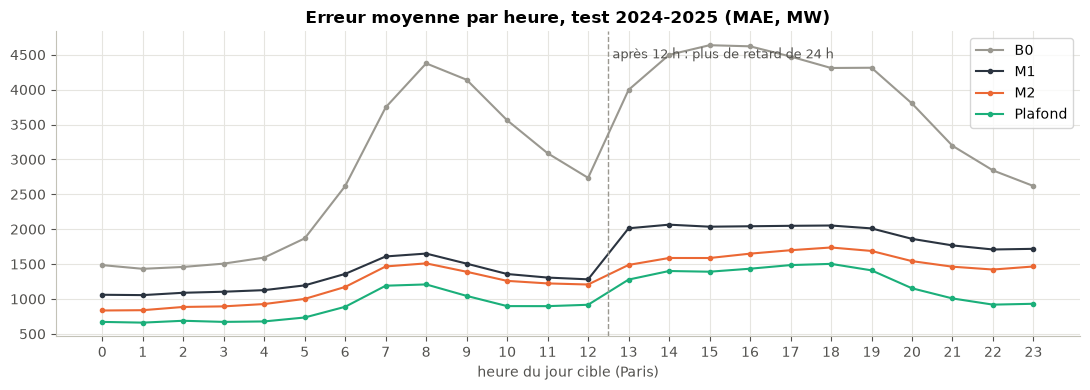

In [12]:
heures = groupes[groupes["critere"] == "heure"].astype({"groupe": int})
heures = heures.pivot(index="groupe", columns="methode", values="MAE_MW")

fig, ax = plt.subplots()
for m in ["B0", "M1", "M2", "Plafond"]:
    ax.plot(heures.index, heures[m], marker="o", ms=3, color=COULEUR[m] if m != "M1" else ENCRE, label=m)
ax.axvline(12.5, color=GRIS, ls="--", lw=1)
ax.text(12.6, ax.get_ylim()[1] * 0.92, "après 12 h : plus de retard de 24 h", color=GRIS_TEXTE, fontsize=9)
ax.set_xticks(range(24))
ax.set_xlabel("heure du jour cible (Paris)")
ax.set_title("Erreur moyenne par heure, test 2024-2025 (MAE, MW)")
ax.legend()
plt.tight_layout()
plt.show()

**Ce que je lis :**

- **L'hiver et le froid sont les cas difficiles** : c'est là que la consommation dépend le plus de
  la température, et une erreur de température coûte cher (environ 2 400 MW par degré sous 15 °C,
  notebook 02). C'est aussi là que la météo apporte le plus : sous 5 °C, M2 fait bien mieux que M1.
- En **été et en automne**, tous les modèles sont bons, et M3 est le meilleur : le gradient
  boosting gère mieux les petits effets des températures douces et chaudes. Mais il perd en hiver,
  qui pèse le plus dans l'erreur totale.
- **Les jours fériés et Noël** restent difficiles, même pour le plafond : ce sont des jours rares,
  avec peu d'exemples pour apprendre.
- **Un férié qui tombe un week-end** (le dimanche 14 juillet 2024 et le samedi 1er novembre 2025)
  fait prévoir **beaucoup trop bas** aux modèles linéaires (M2 : environ −3 700 MW, plafond :
  −5 000 MW), mais pas à M3 ni à B1. Mon explication : une régression **additionne** l'effet
  « dimanche » et l'effet « férié », alors qu'un dimanche férié ressemble simplement à un dimanche.
  Les arbres de M3, eux, savent traiter la combinaison à part. Avec 2 jours seulement, ce n'est
  qu'une piste, mais elle est cohérente (amélioration possible : ne compter le férié que les jours
  ouvrés).
- **Par heure** : l'erreur augmente après midi. Pour les heures 13 à 23, la consommation de la
  veille à la même heure n'est pas encore connue à 14 h, et le modèle doit se contenter de
  l'avant-veille.

## 7. Les 3 pires jours de M2 (test 2024-2025)

L'énoncé demande d'expliquer trois jours où le modèle s'est trompé.

In [13]:
pires = lire("pires_jours_m2_2024_2025")
display(pires.round(1))

,jour_cible,jour_semaine,MAE_MW,biais_MW,erreur_pointe_MW,type_jour,temperature_jour_cible_C,temperature_veille_C,MAE_B0_MW,MAE_B1_MW,MAE_Plafond_MW
0,2025-01-05,Sunday,8206.8,8206.8,8116.6,week-end,9.7,2.1,9523.3,4394.9,959.5
1,2024-11-24,Sunday,7732.1,7732.1,7788.3,week-end,13.6,5.5,13225.4,1623.6,745.8
2,2024-12-24,Tuesday,7075.4,7075.4,7065.8,Noël,6.7,5.8,2458.9,6453.3,5612.2


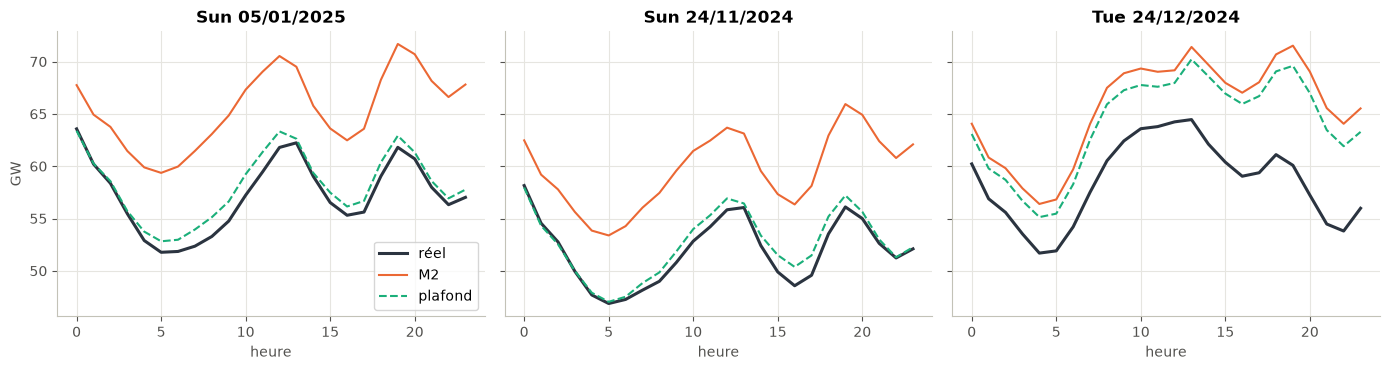

In [14]:
m2 = lire("predictions_test_final_m2_2024_2025")
plafond = lire("predictions_test_final_plafond_2024_2025")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, jour in zip(axes, pires["jour_cible"]):
    a = m2[m2["jour_cible"] == jour].sort_values("heure_cible")
    b = plafond[plafond["jour_cible"] == jour].sort_values("heure_cible")
    ax.plot(a["heure_cible"], a["consommation_cible_MW"] / 1000, color=ENCRE, lw=2.2, label="réel")
    ax.plot(a["heure_cible"], a["prediction_MW"] / 1000, color=ORANGE, label="M2")
    ax.plot(b["heure_cible"], b["prediction_MW"] / 1000, color=VERT, ls="--", label="plafond")
    ax.set_title(pd.Timestamp(jour).strftime("%a %d/%m/%Y"))
    ax.set_xlabel("heure")
axes[0].set_ylabel("GW")
axes[0].legend()
plt.tight_layout()
plt.show()

**Ce que je lis :** M2 prévoit trop ces trois jours-là (biais positif), pour deux raisons différentes.

1. **Dimanche 5 janvier 2025** et **dimanche 24 novembre 2024** : la veille était froide (2 °C et
   5,5 °C), le jour cible beaucoup plus doux (9,7 °C et 13,6 °C). À 14 h la veille, M2 ne connaît que
   la température observée, pas la prévision : il prévoit un jour froid. Avec la vraie météo, le
   plafond ramène l'erreur d'environ 8 000 MW à moins de 1 000 MW. **Cause : pas de prévision
   météo.**
2. **Mardi 24 décembre 2024** : même le plafond se trompe de plus de 5 000 MW. Ce n'est pas la
   météo, c'est le **calendrier** : la veille de Noël ressemble à un jour férié, et la variable
   « période de Noël » avait été écartée parce qu'elle n'aidait pas **en moyenne** sur 2023.

Ces deux causes donnent les deux améliorations les plus utiles : ajouter une **prévision météo**
(disponible à 14 h chez Météo-France) et traiter **les jours spéciaux de fin d'année** à part.

## 8. Le classement est-il stable, et les écarts sont-ils réels ?

**Les écarts sont-ils dus au hasard ?** Le test de Diebold-Mariano compare deux méthodes jour par
jour, sur les mêmes jours. Si la p-valeur dépasse 0,05, l'écart entre elles peut s'expliquer par le
hasard : on ne peut pas dire que l'une est meilleure. Je compare M2 à chaque autre méthode.

In [15]:
colonnes = ["autre_methode", "perte", "ecart_moyen", "p_valeur", "part_jours_reference_meilleure", "conclusion"]
for nom, titre in [("significativite_2023", "Validation 2023"), ("significativite_2024_2025", "Test 2024-2025")]:
    t = lire(nom)
    t = t[t["perte"] == "MAE"][colonnes].assign(autre_methode=lambda d: d["autre_methode"].map(COURT))
    print(f"{titre} : M2 contre chaque méthode (perte = MAE du jour ; écart négatif = M2 meilleur)")
    display(t.round(3))

Validation 2023 : M2 contre chaque méthode (perte = MAE du jour ; écart négatif = M2 meilleur)


,autre_methode,perte,ecart_moyen,p_valeur,part_jours_reference_meilleure,conclusion
0,B0,MAE,-1812.620,0.000,0.712,référence meilleure
2,B1,MAE,-1967.529,0.000,0.706,référence meilleure
4,B2,MAE,-2662.380,0.000,0.798,référence meilleure
6,M1,MAE,-46.677,0.443,0.518,écart non significatif
8,M3,MAE,-79.754,0.274,0.518,écart non significatif
10,M4,MAE,-19.798,0.752,0.482,écart non significatif
12,Plafond,MAE,249.041,0.000,0.429,autre méthode meilleure


Test 2024-2025 : M2 contre chaque méthode (perte = MAE du jour ; écart négatif = M2 meilleur)


,autre_methode,perte,ecart_moyen,p_valeur,part_jours_reference_meilleure,conclusion
0,B0,MAE,-1874.136,0.000,0.804,référence meilleure
2,B1,MAE,-2006.391,0.000,0.729,référence meilleure
4,B2,MAE,-2318.189,0.000,0.801,référence meilleure
6,M1,MAE,-253.638,0.000,0.563,référence meilleure
8,M3,MAE,-18.618,0.603,0.495,écart non significatif
10,M4,MAE,-260.770,0.000,0.581,référence meilleure
12,Plafond,MAE,286.614,0.000,0.373,autre méthode meilleure


**Ce que je lis :**

- M2 bat **nettement** les benchmarks sur les deux périodes, et le plafond bat nettement M2 :
  une prévision météo aiderait vraiment.
- **En 2023, M2 n'est pas significativement meilleur que M1, M3 ou M4.** C'est une année où la
  température aide peu.
- **Sur le test, M2 bat nettement M1 et M4** : la météo apporte un vrai gain. Mais **M2 et M3 sont à
  égalité** : M2 gagne la moitié des jours, M3 l'autre moitié (p = 0,60).

Je retiens donc M2 non pas parce qu'il serait « le meilleur », mais parce qu'à précision égale il
est **plus simple** (une régression qu'on peut expliquer), **meilleur en hiver** (la saison des
grosses consommations, la plus importante pour le réseau) et **plus stable** que M3 entre la
validation et le test.

In [16]:
trimestres = groupes[groupes["critere"] == "trimestre"].pivot(index="groupe", columns="methode", values="MAE_MW")
trimestres = trimestres[["M1", "M2", "M3", "Plafond"]]
trimestres["meilleur entre M2 et M3"] = np.where(trimestres["M2"] < trimestres["M3"], "M2", "M3")
display(trimestres.round(0))

methode,M1,M2,M3,Plafond,meilleur entre M2 et M3
groupe,,,,,
2024-T1,2413.0,1967.0,2080.0,1252.0,M2
2024-T2,1108.0,973.0,1039.0,888.0,M2
2024-T3,924.0,942.0,718.0,948.0,M3
2024-T4,1900.0,1565.0,1667.0,1130.0,M2
2025-T1,2348.0,1729.0,2030.0,1217.0,M2
2025-T2,1125.0,1099.0,969.0,882.0,M3
2025-T3,967.0,917.0,769.0,944.0,M3
2025-T4,1922.0,1472.0,1555.0,1097.0,M2


Par trimestre, M2 gagne tous les hivers et automnes (T1 et T4), M3 gagne les étés (T3) et le
printemps 2025. Le classement M2 / M3 **dépend donc de la saison** : c'est une raison de plus pour
parler d'égalité.

Je compare enfin les deux années du test, chacune sur ses jours communs.

In [17]:
annees = lire("comparaison_test_2024_2025_par_annee").assign(methode=lambda d: d["methode"].map(COURT))
mae_annee = annees.pivot(index="methode", columns="annee", values="MAE (MW)")
mae_annee["rang 2024"] = mae_annee[2024].rank().astype(int)
mae_annee["rang 2025"] = mae_annee[2025].rank().astype(int)
display(mae_annee.round(0).sort_values(2024))

annee,2024,2025,rang 2024,rang 2025
methode,,,,
Plafond,1054.0,1034.0,1,1
M2,1361.0,1300.0,2,2
M3,1374.0,1324.0,3,3
M1,1585.0,1584.0,4,5
M4,1604.0,1579.0,5,4
B1,3226.0,3449.0,6,7
B0,3244.0,3165.0,7,6
B2,3696.0,3602.0,8,8


**Ce que je lis :** les trois premiers (plafond, M2, M3) sont dans le même ordre en 2024 et en
2025, avec des erreurs du même ordre : le choix de M2 ne dépend pas d'une année particulière. M1 et
M4 échangent leur place, mais ils sont à quelques MW l'un de l'autre ; B0 et B1 aussi.

En revanche, M3 change beaucoup de place par rapport à la validation 2023 : dernier des modèles en
2023, juste derrière M2 sur le test. Son classement est donc moins stable que celui de M2.

## 9. Le test bonus : janvier à juin 2026

Un dernier examen, sur des données que personne n'avait vues : janvier à juin 2026 (décision 3).
Il a été lancé **une seule fois**, après tout le reste, avec les configurations gelées et le même
protocole (réestimation chaque mois). Avant de le lancer, nous avons vérifié qu'ajouter les données
de 2026 ne changeait **rien** aux données de 2016-2025 (consommation, météo, table des variables :
identiques) : une preuve de plus que la chaîne n'utilise jamais le futur.

In [18]:
bonus = lire("test_bonus_2026_comparaison").set_index("methode").rename(index=COURT)
display(bonus[["nb_jours", "MAE (MW)", "RMSE (MW)", "MAPE (%)", "biais (MW)",
               "erreur énergie du jour (GWh, absolue)", "erreur pointe (MW, absolue)"]].round(1))

t = lire("test_bonus_2026_significativite")
t = t[t["perte"] == "MAE"][["autre_methode", "ecart_moyen", "p_valeur", "part_jours_reference_meilleure", "conclusion"]]
print("M2 contre chaque méthode (perte = MAE du jour)")
display(t.assign(autre_methode=lambda d: d["autre_methode"].map(COURT)).round(3))

print("Les 3 pires jours de M2")
display(lire("test_bonus_2026_pires_jours_m2").round(1))

,nb_jours,MAE (MW),RMSE (MW),MAPE (%),biais (MW),"erreur énergie du jour (GWh, absolue)","erreur pointe (MW, absolue)"
methode,,,,,,,
B0,178.0,3147.5,4352.2,6.1,122.6,69.7,3318.0
B1,178.0,4054.5,5470.1,7.6,658.0,94.3,4173.7
B2,178.0,4496.8,5865.6,8.5,1379.1,105.4,4498.4
M1,178.0,1780.3,2462.0,3.3,335.9,38.2,1796.5
M2,178.0,1423.5,2002.4,2.6,157.8,30.5,1526.1
M3,178.0,1524.4,2165.4,2.8,232.5,31.6,1675.9
M4,178.0,1746.7,2455.2,3.2,271.5,36.9,1767.2
Plafond,178.0,974.3,1283.7,1.9,120.0,19.0,923.8


M2 contre chaque méthode (perte = MAE du jour)


,autre_methode,ecart_moyen,p_valeur,part_jours_reference_meilleure,conclusion
0,B0,-1723.970,0.000,0.764,référence meilleure
2,B1,-2630.981,0.000,0.888,référence meilleure
4,B2,-3073.291,0.000,0.876,référence meilleure
6,M1,-356.749,0.000,0.669,référence meilleure
8,M3,-100.849,0.064,0.601,écart non significatif
10,M4,-323.222,0.000,0.607,référence meilleure
12,Plafond,449.167,0.000,0.331,autre méthode meilleure


Les 3 pires jours de M2


,jour_cible,jour_semaine,MAE_MW,biais_MW,erreur_pointe_MW,type_jour,temperature_jour_cible_C,temperature_veille_C,MAE_B0_MW,MAE_B1_MW,MAE_Plafond_MW
0,2026-01-08,Thursday,6105.6,6105.6,6517.2,ouvré,5.9,0.2,8248.4,6425.8,1677.5
1,2026-02-16,Monday,5974.0,5974.0,5500.9,ouvré,8.5,4.6,3246.8,1562.7,1501.3
2,2026-01-12,Monday,5317.5,5317.5,6822.9,ouvré,7.3,2.7,2654.0,11566.6,1573.8


**Ce que je lis :**

- **Le classement de 2024-2025 se confirme** : M2 a la plus petite erreur des modèles utilisables
  (environ 1 420 MW), bat nettement M1, M4 et les benchmarks, et reste à égalité statistique avec M3
  (p > 0,05), même s'il gagne 60 % des jours.
- **Le biais a presque disparu** (environ +160 MW, contre +520 MW sur 2024-2025). C'est cohérent
  avec l'explication du point 2 : l'apprentissage contient maintenant 2023-2025, années où la
  consommation était déjà plus basse, et le modèle a rattrapé une partie du nouveau niveau.
- **Les 3 pires jours sont encore des redoux** après un jour froid (le jour cible est 4 à 6 °C plus
  doux que la veille). La vraie météo divise l'erreur par 3 à 4 : c'est la même cause qu'en
  2024-2025, le manque de prévision météo.
- Limites : 6 mois seulement (surtout hiver et printemps), données 2026 consolidées que RTE peut
  encore corriger.

## 10. Ce qu'il faut retenir, et les limites

**Le modèle à présenter est M2** : une régression linéaire par heure, avec le calendrier, les
consommations connues à 14 h et la température observée jusqu'à 13 h. Sur 2024-2025, il se trompe
en moyenne de 1 331 MW, soit environ 2,6 %, environ 2,4 fois moins que le meilleur benchmark (B0).
Sur le test bonus de 2026, jamais vu, il fait 1 424 MW : le résultat tient.
Le gradient boosting (M3) fait jeu égal : la complexité supplémentaire n'apporte pas de gain
significatif, elle déplace seulement les erreurs de l'hiver vers l'été.

**Quand ne pas lui faire confiance :** les changements brusques de température (il n'a pas de
prévision météo), les jours de fin d'année, les jours fériés (surtout un férié tombant un
week-end), et les périodes où le niveau de consommation change (il surestime depuis 2023).

**Limites à dire honnêtement :**

- Le test 2024-2025 de M1 et M2 a été lancé **avant** que M3 et M4 soient construits. Leurs réglages
  ont été choisis sur 2023 seulement, mais nous connaissions déjà le score de M2 sur le test.
- M4 contenait une petite fuite (l'heure 13 du jour J) : elle a été corrigée et son test relancé.
- Le test de sensibilité au confinement, promis par la décision 9, n'a été fait qu'après le gel :
  il montre que garder ces jours aurait été meilleur sur 2023.
- Les données de consommation sont les versions définitives ou consolidées de RTE, un peu plus
  propres que ce qui était disponible à 14 h le jour même.